In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf


## 1) Model du CAPM:  

$$E(R_i) = R_f + \beta_{i}(E(R_m)-R_f)$$
$$\beta_{i} = \dfrac{Cov(R_i;R_m)}{Var(R_m)}$$

Où:  
$R_f$: taux sans risque (ex: obligation d'état, bon du trésor)  
$R_m$: représente le rendement de l'ensemble du marché (ou d'un indice de marché représentatif)  
$\beta$: rémuneration structuelle  




In [10]:
# calcule du beta ainsi que des parametres : 
def Cov(X, Y):
    return np.mean((X - np.mean(X)) * (Y - np.mean(Y)))
def Var(X):
    return np.mean((X - np.mean(X)) ** 2)
def Beta(X, Y):
    return Cov(X, Y) / Var(X)



In [11]:
pf = yf.download(["AAPL", "^GSPC"], start='2020-01-01')['Close'].pct_change().dropna()
pf_beta = Beta(pf["AAPL"], pf["^GSPC"])
print("Beta de Apple par rapport à l'indice SP500 : ", pf_beta)

C:\Users\Tom\AppData\Local\Temp\ipykernel_15568\2707764284.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf = yf.download(["AAPL", "^GSPC"], start='2020-01-01')['Close'].pct_change().dropna()
[*********************100%***********************]  2 of 2 completed

Beta de Apple par rapport à l'indice SP500 :  0.509145233658834


Text(0, 0.5, 'Rendement AAPL')

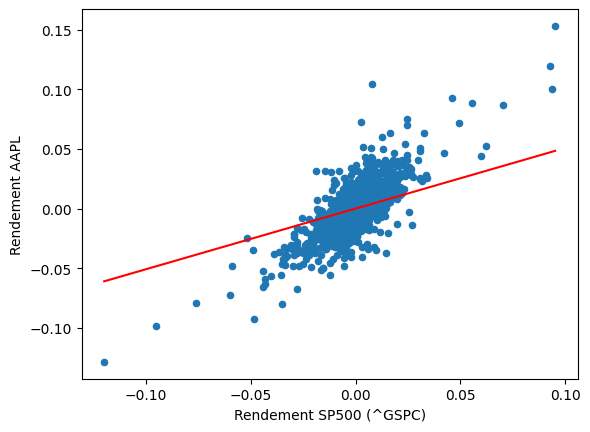

In [12]:
pf.plot.scatter(x='^GSPC', y='AAPL')
x_line = np.linspace(pf['^GSPC'].min(), pf['^GSPC'].max(), 1000)
y_line = pf_beta * x_line
plt.plot(x_line, y_line, color='red', label='Ligne de régression')
plt.xlabel('Rendement SP500 (^GSPC)')
plt.ylabel('Rendement AAPL')

calcule de $E(R_m)$ avec la Prime de risque historique + taux sans risque  

$E(R_m) = R_f + prime\ de\ risque\ historique $  

avec :  
$prime\ de\ risque\ historique = \dfrac{1}{T} \Sigma (R_{m,t} - R_{f,t}) $  

Comme on va faire un pf a valeur usa je pense que je vais prendre une obligation du tresort a 10 ans américaine pour ça.  
$R_f$ = US 10 Year Treasury Note Yield


In [77]:
sp500 = yf.download("^GSPC", start = "2000-01-01",interval= '1mo')['Close']
us10Y = yf.download("^TNX", start="2000-01-01",interval= '1mo')['Close']

## passage des données en annuel car yfinance ne le fait pas... 
sp500_yearly = sp500.resample('YE').last()
us10_yearly = us10Y.resample('YE').mean()

sp500_returns = sp500_yearly.pct_change().dropna() * 100 

sp500_returns.head()

data = pd.concat([sp500_returns,us10_yearly], axis=1).dropna()
data.head(10)






C:\Users\Tom\AppData\Local\Temp\ipykernel_15568\1357649826.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start = "2000-01-01",interval= '1mo')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Tom\AppData\Local\Temp\ipykernel_15568\1357649826.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  us10Y = yf.download("^TNX", start="2000-01-01",interval= '1mo')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC,^TNX
Date,,
2001-12-31,-13.042693,4.967500
2002-12-31,-23.365964,4.533250
2003-12-31,26.380400,3.997667
2004-12-31,8.993452,4.255083
2005-12-31,3.001023,4.269000
2006-12-31,13.619432,4.781167
2007-12-31,3.529573,4.578833
2008-12-31,-38.485793,3.598250
2009-12-31,23.454190,3.277250
